# Hypothesis 1 Analysis

This notebook tests Hypothesis 1 for the improbable-bigram repetition setup:

- token induction heads should keep attending to the desired earlier suffix token, measured with `NTM`
- token induction heads should keep contributing to the correct second-token prediction, measured with `DLA`

The notebook uses the traced cache in `updated_table1_literal` plus the random two-token control set in `random_tokens`.


In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    candidates = []
    for candidate in (start, *start.parents):
        candidates.extend(
            [
                candidate,
                candidate / "dual-route-induction",
                candidate / "improbable-bigram-causality" / "dual-route-induction",
            ]
        )

    for candidate in candidates:
        if (candidate / "cache").exists() and (candidate / "scripts").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not locate the dual-route-induction repo root from the current working directory."
    )


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

import hypothesis1_utils as h1

h1.configure_matplotlib()
CACHE = h1.load_cache(ROOT)
DEFAULT_TOP_K = 32
ROOT

WindowsPath('D:/uni/courses/S2026/CS_7180/Project/improbable-bigram-causality/dual-route-induction')

In [2]:
display(Markdown(h1.trace_consistency_markdown(CACHE)))
overview = h1.dataset_overview(CACHE)
display(overview)

### Trace Consistency
The prompt-summary JSON is not present in this repo snapshot. The notebook therefore uses the traced cache directly.

,dataset,examples,hallucinated_second_token,copied
0,Improbable summary,100,33,67
1,Updated trace cache,100,33,67
2,Random phrase cache,35,0,35


In [3]:
summary = h1.build_pairwise_summary(CACHE, DEFAULT_TOP_K)
display(summary.round(6))
display(Markdown(h1.interpretation_markdown(CACHE, DEFAULT_TOP_K)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Token NTM (raw),Hallucinated - Copied,0.024730,0.023275,0.001455,-0.000551,0.003349
1,Token NTM (raw),Hallucinated - Random,0.024730,0.048698,-0.023968,-0.028014,-0.020336
2,Token NTM (value-weighted),Hallucinated - Copied,0.041541,0.040771,0.000770,-0.002189,0.003553
3,Token NTM (value-weighted),Hallucinated - Random,0.041541,0.074148,-0.032608,-0.038103,-0.027238
4,Token correct-token DLA,Hallucinated - Copied,0.027389,0.032406,-0.005017,-0.011759,0.001962
5,Token correct-token DLA,Hallucinated - Random,0.027389,0.068041,-0.040652,-0.051702,-0.029943
6,Hallucinated token DLA,Wrong-token - Correct-token,0.004627,0.027389,-0.022763,-0.031545,-0.012939


### Hypothesis 1 Readout at Top-32
- Hallucinated vs copied NTM: `0.0015` (95% CI `-0.0006` to `0.0033`)
- Hallucinated vs copied correct-token DLA: `-0.0050` (95% CI `-0.0118` to `0.0020`)
- Hallucinated vs random NTM: `-0.0240` (95% CI `-0.0280` to `-0.0203`)
- Hallucinated vs random correct-token DLA: `-0.0407` (95% CI `-0.0517` to `-0.0299`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0228` (95% CI `-0.0315` to `-0.0129`)

Within the improbable-bigram set, the traced cache does not show a clear hallucination-specific token-head breakdown. The stronger claim that token-head behavior is similar across all conditions is harder to defend, because the random-phrase control is much stronger on both NTM and correct-token DLA.

,metric,condition,k,mean,ci_low,ci_high
0,Token NTM (raw),Hallucinated improbable,8,0.046329,0.042530,0.050190
1,Token NTM (raw),Copied improbable,8,0.040627,0.037449,0.044055
2,Token NTM (raw),Random phrases,8,0.082889,0.073416,0.093634
3,Token NTM (raw),Hallucinated improbable,16,0.031126,0.028741,0.033655
4,Token NTM (raw),Copied improbable,16,0.028339,0.026312,0.030403
5,Token NTM (raw),Random phrases,16,0.058136,0.051863,0.065144
6,Token NTM (raw),Hallucinated improbable,32,0.024730,0.023345,0.026160
7,Token NTM (raw),Copied improbable,32,0.023275,0.021956,0.024709
8,Token NTM (raw),Random phrases,32,0.048698,0.045353,0.052579
9,Token NTM (raw),Hallucinated improbable,64,0.023890,0.022810,0.025029


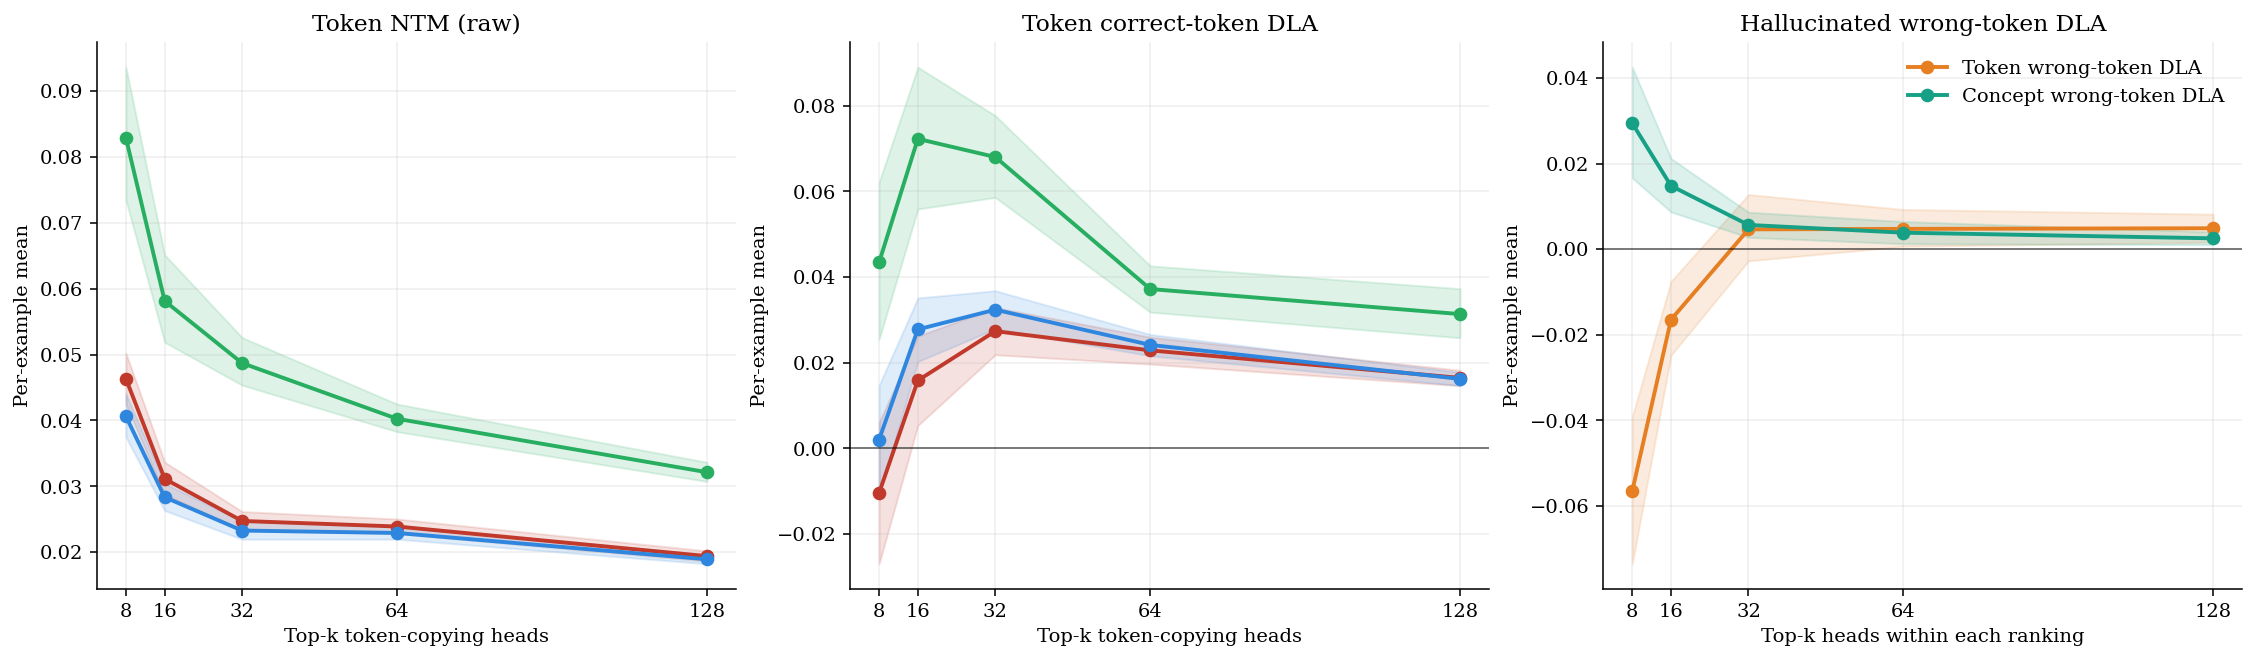

In [4]:
fig, axes, sweep = h1.plot_k_sweep(CACHE, ks=(8, 16, 32, 64, 128))
display(sweep.round(6))

(<Figure size 1680x672 with 2 Axes>,
 array([<Axes: title={'center': 'Top-32 token-head NTM'}, ylabel='Per-example mean'>,
        <Axes: title={'center': 'Top-32 token-head correct-token DLA'}, ylabel='Per-example mean'>],
       dtype=object))

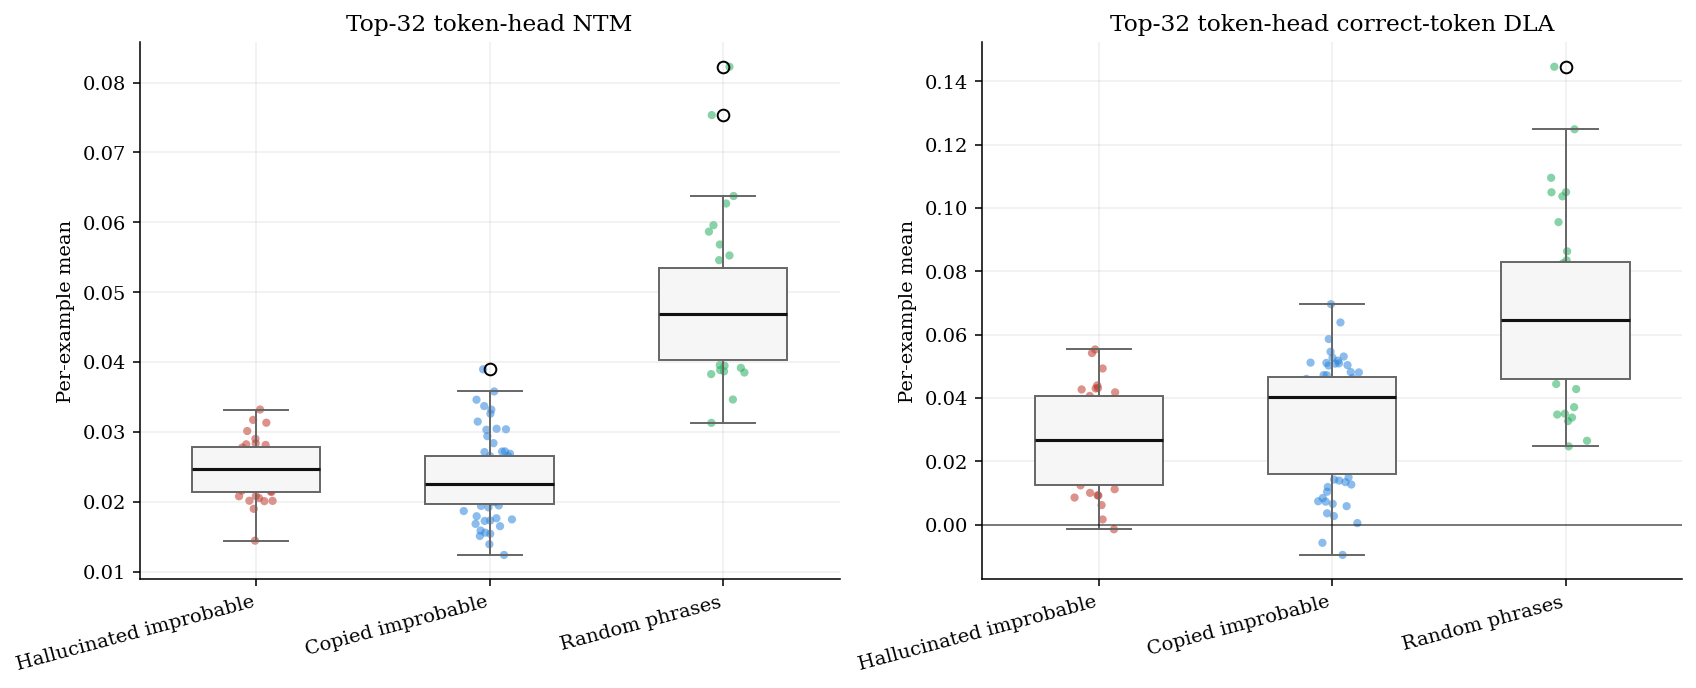

In [5]:
h1.plot_distribution_panels(CACHE, DEFAULT_TOP_K)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 token heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

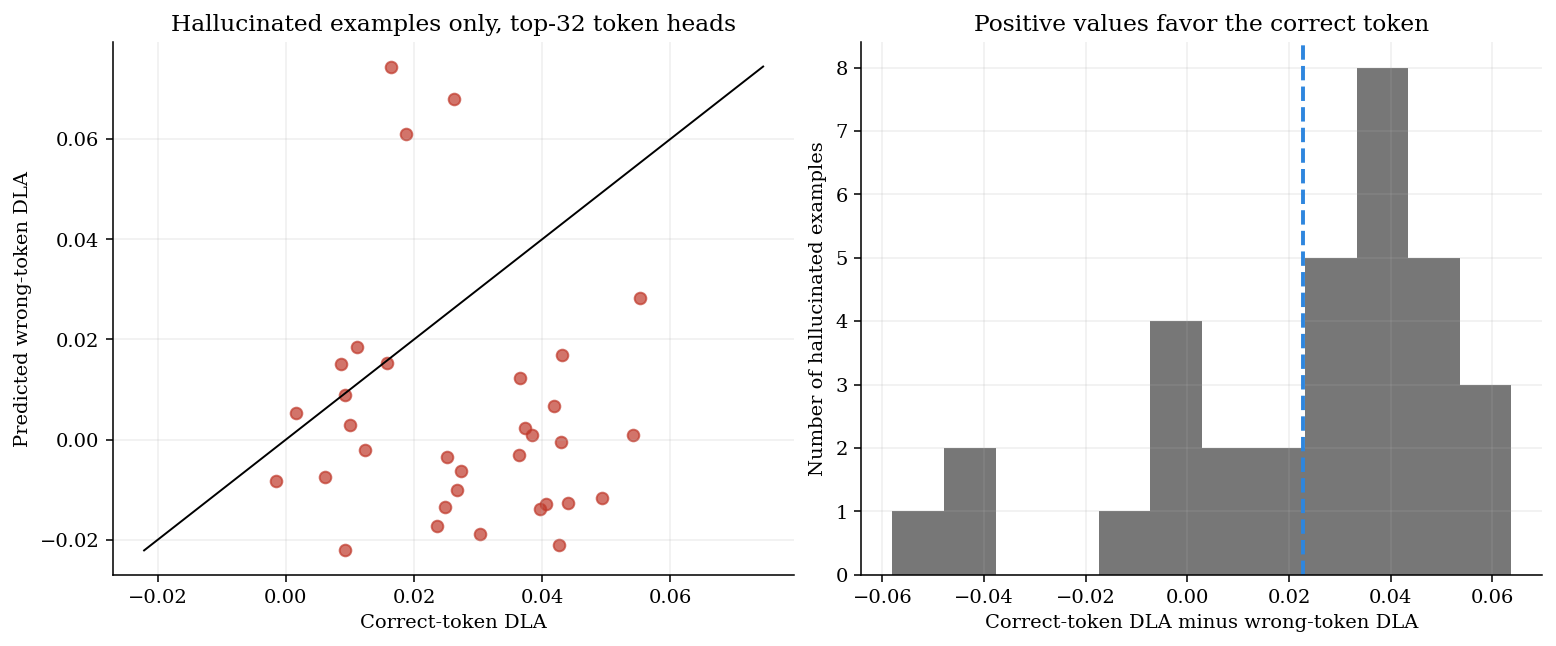

In [6]:
h1.plot_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

(<Figure size 1680x784 with 4 Axes>,
 array([<Axes: title={'center': 'Top-16 token heads: NTM'}>,
        <Axes: title={'center': 'Top-16 token heads: DLA'}>], dtype=object))

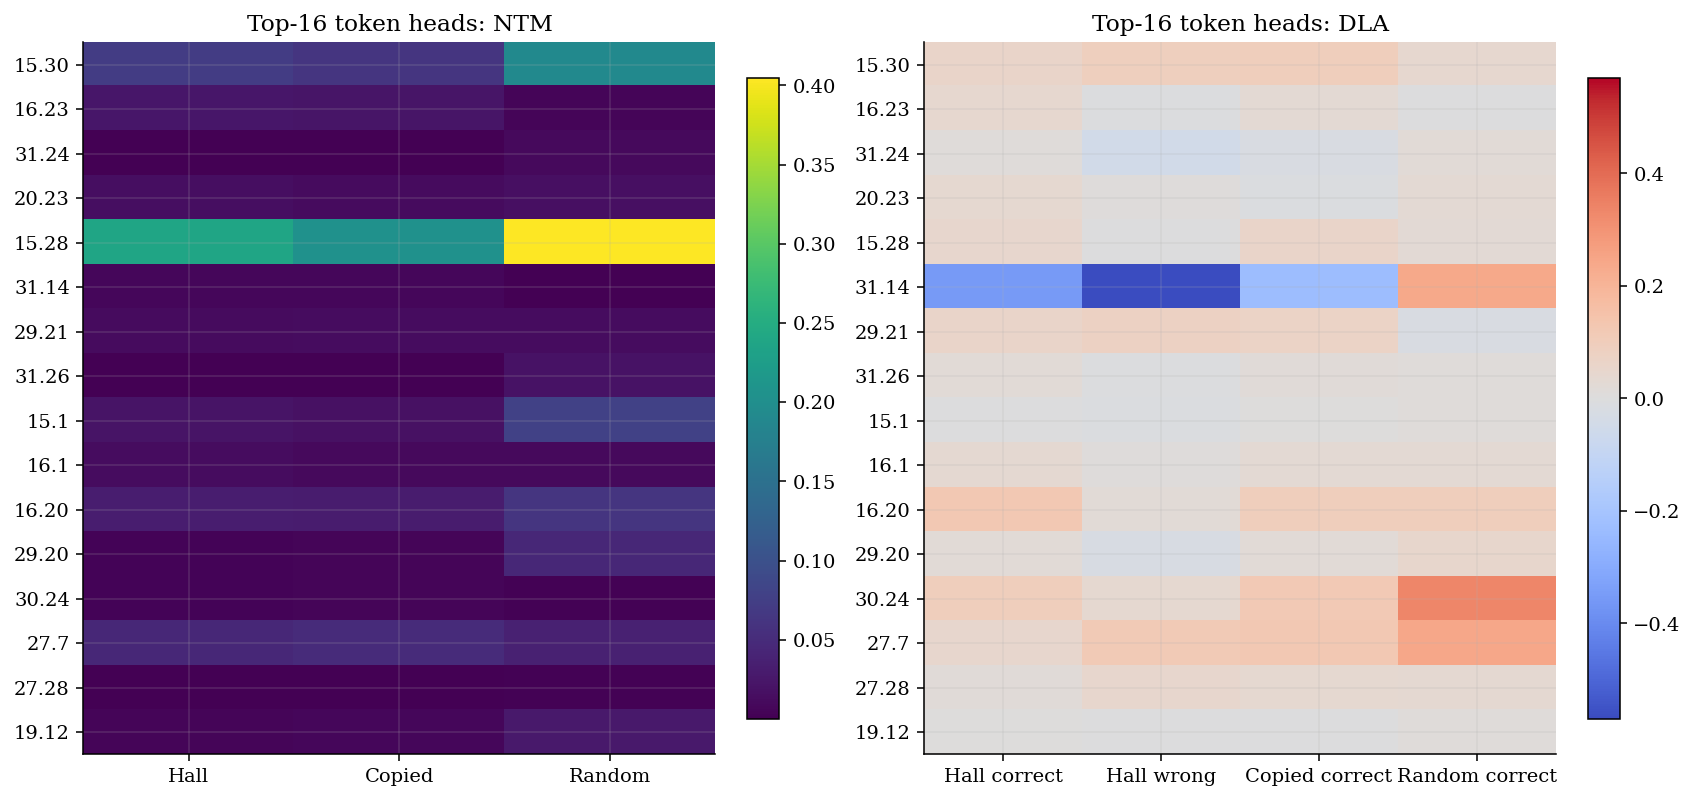

In [7]:
h1.plot_top_head_heatmap(CACHE, top_k=16)

## Are The Highest-DLA Heads Token-Copying Or Concept-Copying?

This section ranks heads by mean DLA and checks whether those heads also appear in the identified token-copying or concept-copying rankings.


In [8]:
TOP_DLA_N = 20
COMPARE_K = 32
SOURCES = [
    "hallucinated_correct",
    "hallucinated_wrong",
    "copied_correct",
    "random_correct",
]

membership_summary = h1.summarize_top_dla_membership(
    CACHE,
    sources=SOURCES,
    top_n=TOP_DLA_N,
    compare_k=COMPARE_K,
)
display(membership_summary)

for source in SOURCES:
    table = h1.top_dla_membership_table(
        CACHE,
        source=source,
        top_n=TOP_DLA_N,
        compare_k=COMPARE_K,
    )
    display(Markdown(f"### {table['source'].iloc[0]}"))
    display(
        table[
            [
                "head",
                "mean_dla",
                "membership_label",
                "in_token_top_k",
                "in_concept_top_k",
                "token_rank",
                "concept_rank",
            ]
        ].round({"mean_dla": 6})
    )

,source,top_n,compare_k,token_overlap,concept_overlap,both_overlap,neither_overlap,mean_token_rank,mean_concept_rank
0,Hallucinated correct-token DLA,20,32,3,1,0,16,289.70,348.55
1,Hallucinated wrong-token DLA,20,32,3,2,0,15,333.40,325.55
2,Copied-improbable correct-token DLA,20,32,3,2,0,15,342.85,315.90
3,Random-phrase correct-token DLA,20,32,4,0,0,16,315.25,420.15


### Hallucinated correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.630886,Token only,True,False,32,300
1,27.6,0.550378,Neither,False,False,675,164
2,26.13,0.407651,Neither,False,False,376,42
3,22.1,0.385917,Neither,False,False,401,154
4,26.3,0.381923,Neither,False,False,35,667
5,20.1,0.297932,Concept only,False,True,406,5
6,24.18,0.282678,Neither,False,False,150,624
7,29.9,0.205844,Neither,False,False,419,503
8,28.22,0.190377,Neither,False,False,373,175
9,31.20,0.183341,Neither,False,False,371,297


### Hallucinated wrong-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.468839,Token only,True,False,32,300
1,24.22,0.374964,Neither,False,False,156,223
2,29.9,0.287445,Neither,False,False,419,503
3,30.26,0.243680,Neither,False,False,103,482
4,31.5,0.222435,Neither,False,False,1003,289
5,27.6,0.212589,Neither,False,False,675,164
6,26.3,0.209088,Neither,False,False,35,667
7,28.0,0.202645,Neither,False,False,454,558
8,22.1,0.187615,Neither,False,False,401,154
9,26.13,0.179703,Neither,False,False,376,42


### Copied-improbable correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.599462,Token only,True,False,32,300
1,27.6,0.464505,Neither,False,False,675,164
2,26.13,0.379171,Neither,False,False,376,42
3,26.3,0.355348,Neither,False,False,35,667
4,29.9,0.265404,Neither,False,False,419,503
5,20.1,0.225269,Concept only,False,True,406,5
6,27.20,0.218328,Concept only,False,True,397,4
7,31.20,0.210226,Neither,False,False,371,297
8,30.12,0.193650,Neither,False,False,553,378
9,31.21,0.160162,Neither,False,False,383,299


### Random-phrase correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.0,0.728313,Token only,True,False,20,318
1,27.4,0.509023,Neither,False,False,144,346
2,30.12,0.354871,Neither,False,False,553,378
3,28.20,0.353128,Neither,False,False,140,103
4,30.24,0.334439,Token only,True,False,13,336
5,24.18,0.307862,Neither,False,False,150,624
6,25.14,0.295445,Neither,False,False,99,643
7,30.30,0.294079,Neither,False,False,74,585
8,24.16,0.292921,Neither,False,False,597,398
9,25.15,0.285971,Neither,False,False,216,660


WindowsPath('D:/uni/courses/S2026/CS_7180/Project/improbable-bigram-causality/dual-route-induction/scripts/hypothesis1_figures')

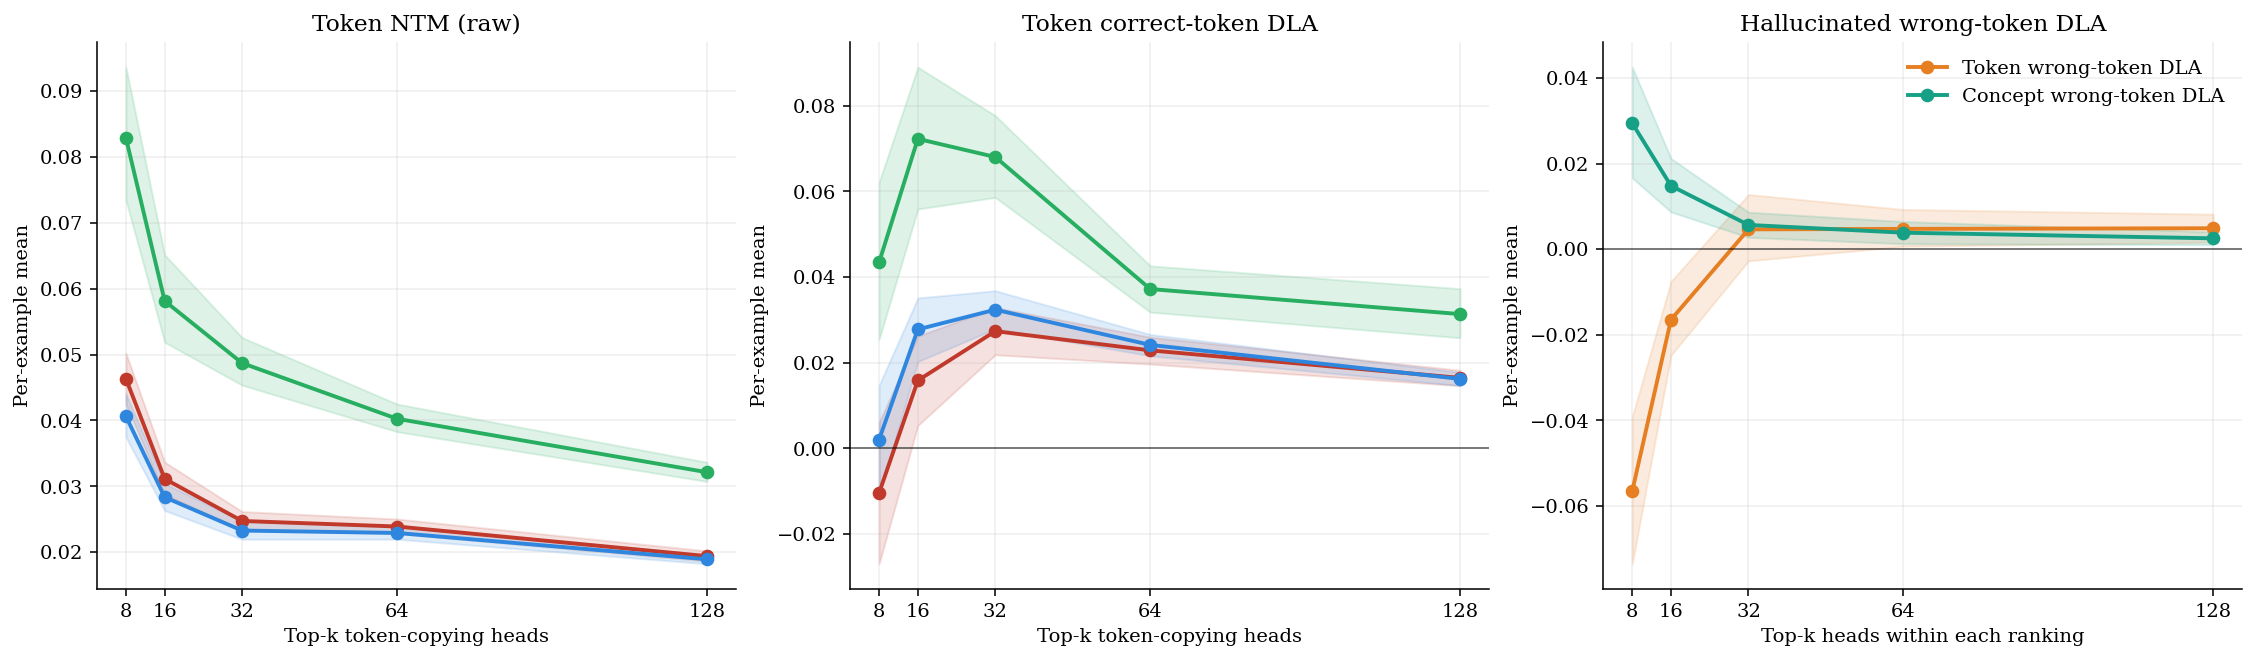

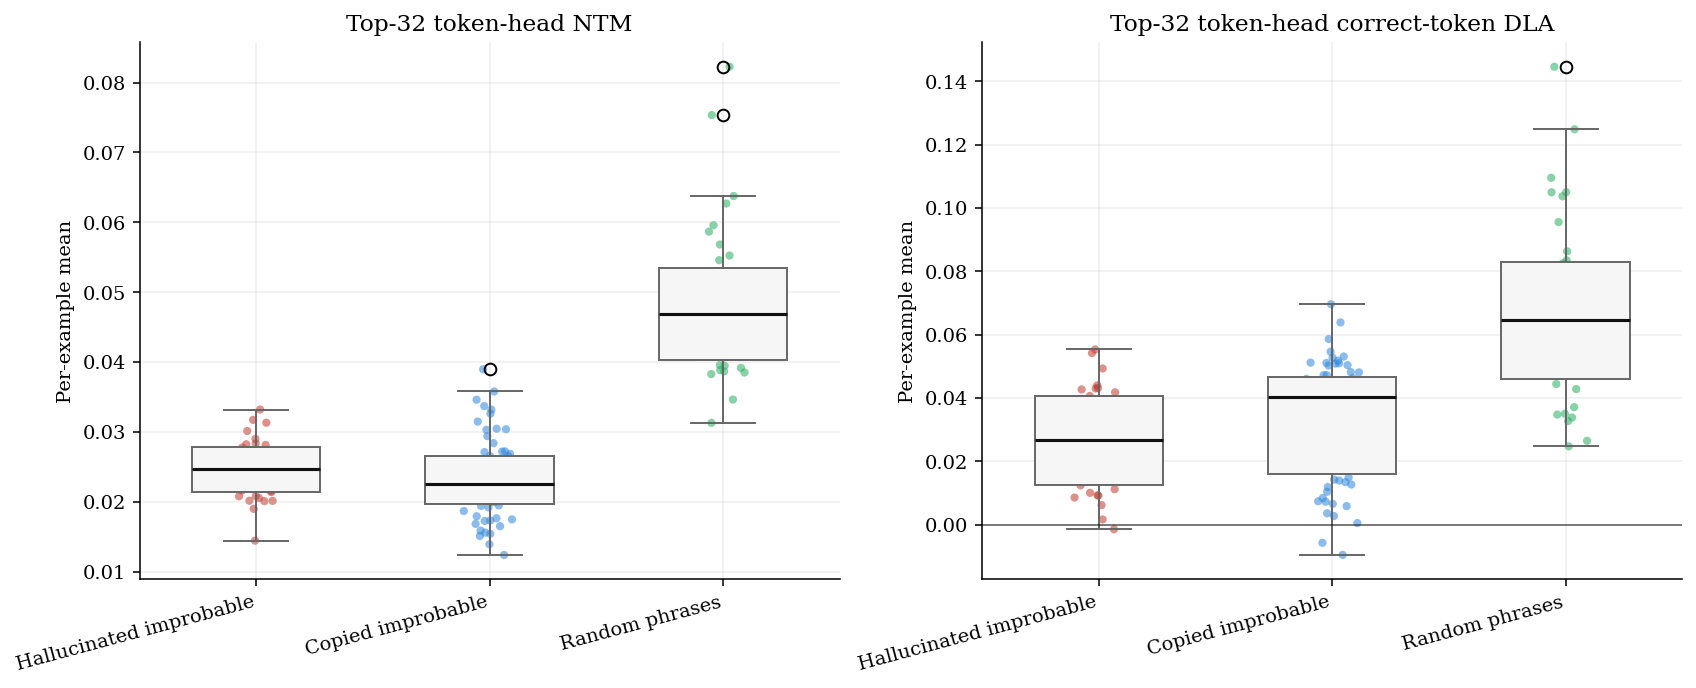

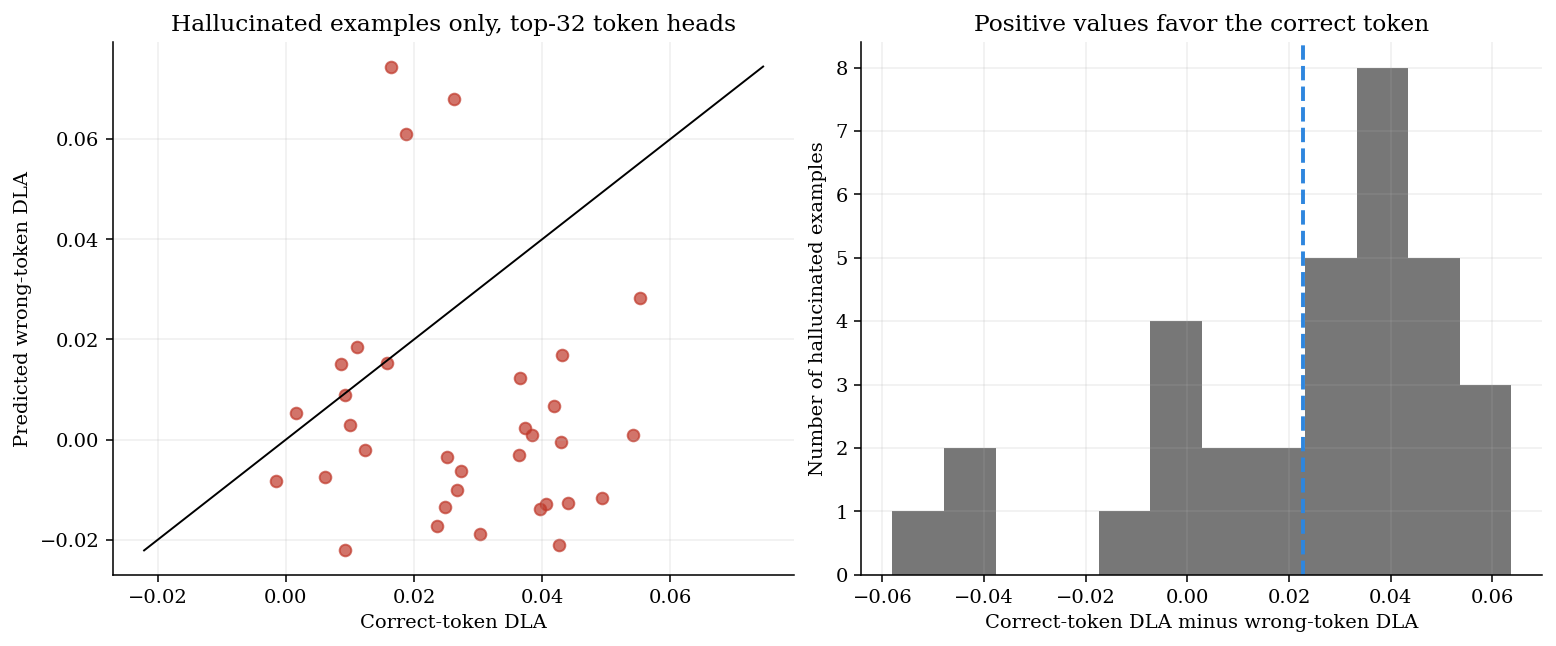

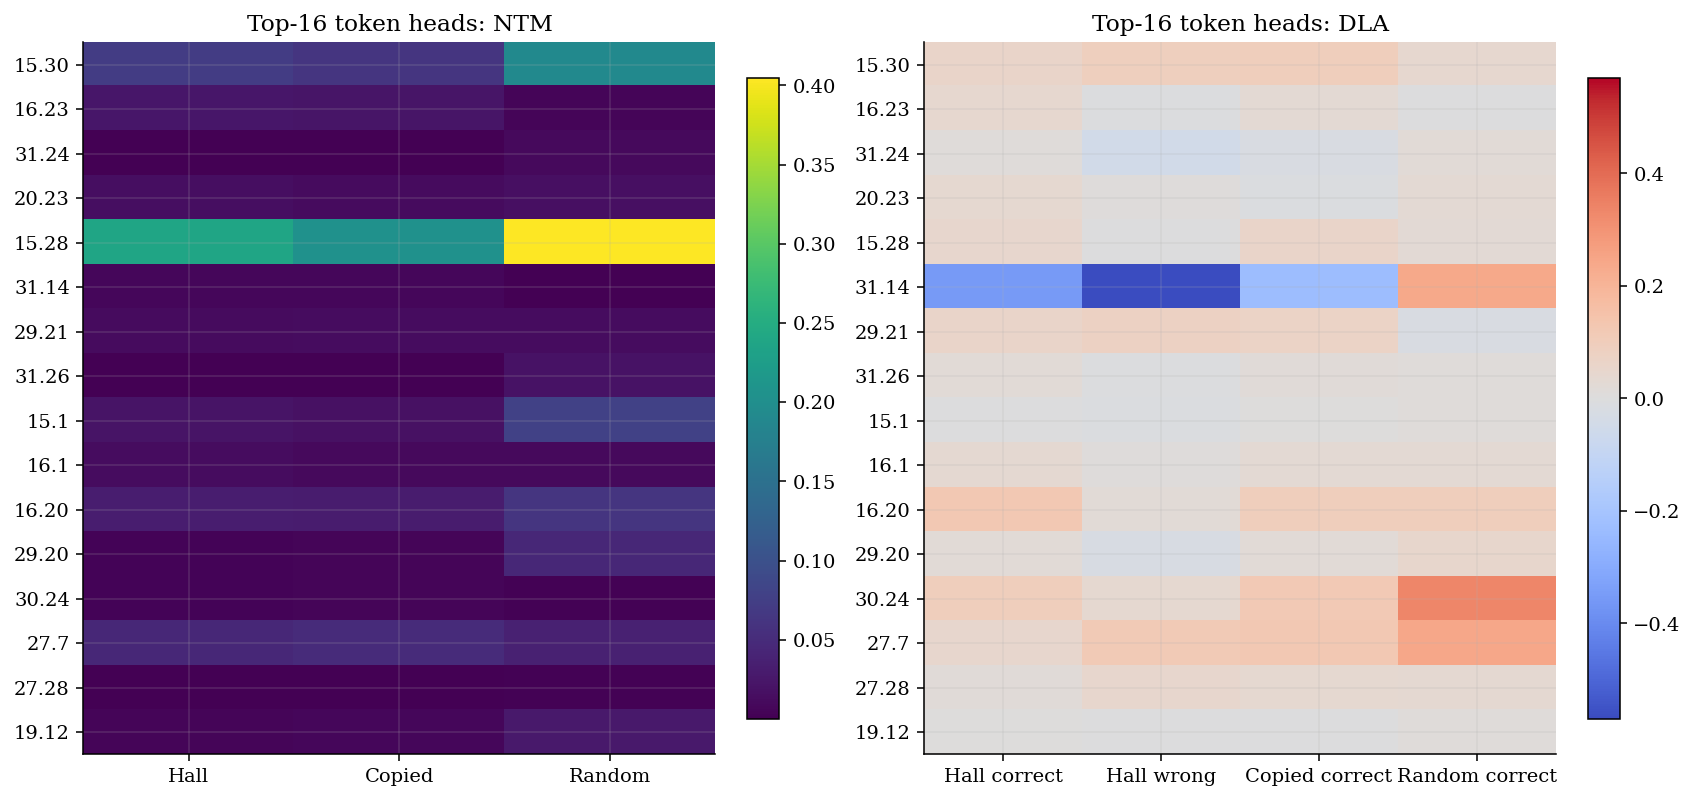

In [9]:
SAVE_DIR = ROOT / "scripts" / "hypothesis1_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_k_sweep(
    CACHE, ks=(8, 16, 32, 64, 128), save_path=SAVE_DIR / "hypothesis1_k_sweep.png"
)
_ = h1.plot_distribution_panels(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "hypothesis1_distributions.png"
)
_ = h1.plot_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "hypothesis1_hallucinated_dla_pair.png"
)
_ = h1.plot_top_head_heatmap(
    CACHE, top_k=16, save_path=SAVE_DIR / "hypothesis1_top_token_heads.png"
)
SAVE_DIR